# Zou_lab_control.frontend tutorial

这个 notebook 展示统一的 Jupyter 画图接口。第一格只做一次轻量 API 检查：正常使用时只需要 `import Zou_lab_control.frontend as zf` 和 `zf.notebook_setup()`。

如果这个 import 失败，说明当前 kernel 还没有安装本仓库；在项目根目录执行一次 `python -m pip install -e .` 后重启 kernel 即可。这个安装步骤不应该反复塞进每个 notebook cell。

In [1]:
try:
    import Zou_lab_control.frontend as zf
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install once from the project root with `python -m pip install -e .`, then restart this kernel.") from exc

zf.notebook_setup()

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

import Zou_lab_control.frontend as zf

try:
    zf.use_widget_backend()
except Exception as exc:
    print(f"Widget backend not enabled here: {exc}")

zf.enable_long_output()
zf.apply_style()

## 1D plot, title, and fitting

`zf.plot(x, y)` 的输入契约是 `x: (N, coord_dim)` 和 `y: (N, channel_dim)`。静态图和 live 图都用这套契约；差别只是 live 时有 worker 持续写入共享 array。

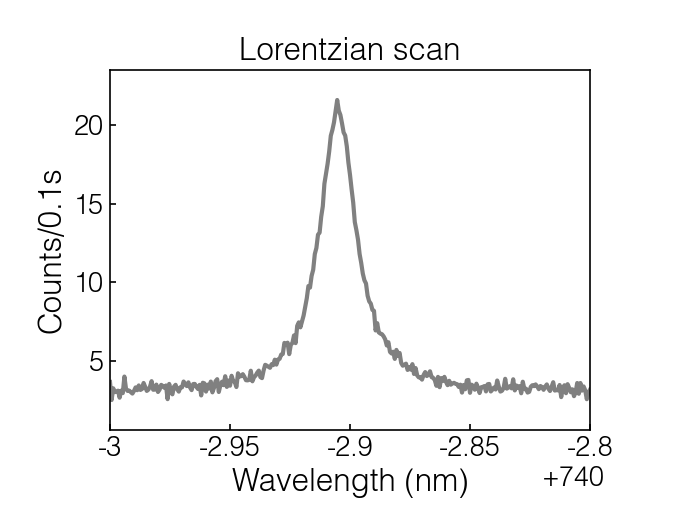

(FitResult(names=['x_0', 'FWHM', 'H', 'B'], popt=array([7.37094966e+02, 1.81217609e-02, 1.79636111e+01, 3.00217751e+00]), pcov=array([[ 1.53329378e-09, -3.17713504e-12,  2.86378279e-09,
         -2.09248884e-10],
        [-3.17713504e-12,  1.66556591e-08, -5.79956848e-06,
         -1.29815707e-06],
        [ 2.86378279e-09, -5.79956848e-06,  6.04972152e-03,
         -8.68321141e-05],
        [-2.09248884e-10, -1.29815707e-06, -8.68321141e-05,
          3.86948224e-04]]), function='lorent'),
 array([7.37094966e+02, 1.81217609e-02, 1.79636111e+01, 3.00217751e+00]))

In [3]:
x = np.linspace(737.0, 737.2, 301).reshape(-1, 1)
y = 18 * ((0.018 / 2) ** 2) / ((x[:, 0] - 737.095) ** 2 + (0.018 / 2) ** 2) + 3
y = (y + np.random.default_rng(3).normal(0, 0.25, size=len(x))).reshape(-1, 1)

ple = zf.plot(
    x,
    y,
    labels=("Wavelength (nm)", "Counts/0.1s", "Counts"),
    relim_mode="tight",
    title="Lorentzian scan",
)
fit_result, popt = ple.data_figure.lorent()
fit_result, popt

## 2D plot

对外的 2D plot 始终保持 square view，避免主图、distribution axis 和 colorbar 视觉错位。内部如果要调试非 square，可以直接使用 `Live2DDis`，但 notebook 正常调用不开放 `square=False`。

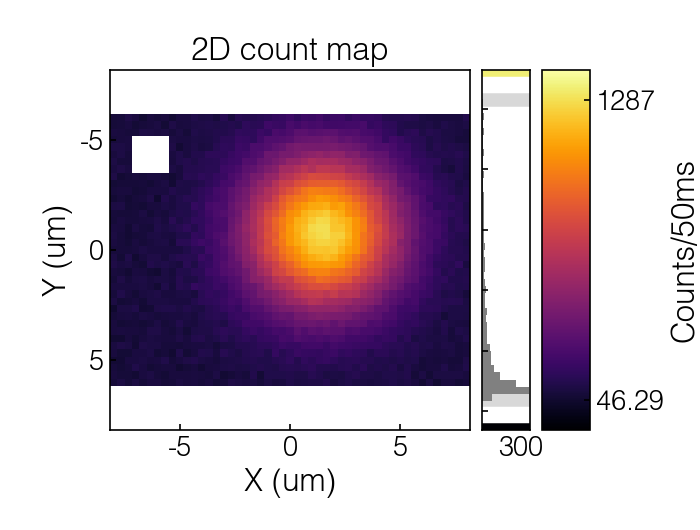

(FitResult(names=['A', 'B', 'R', 'x0', 'y0'], popt=array([ 1.20021994e+03,  8.00796060e+01,  3.46396702e+00,  1.50159711e+00,
        -8.01719173e-01]), pcov=array([[ 2.68072670e+00, -7.91489075e-02, -3.51306782e-03,
         -1.86779496e-05,  6.36866642e-05],
        [-7.91489075e-02,  3.75748878e-01, -1.90812291e-03,
          3.25754507e-05, -5.27583992e-05],
        [-3.51306782e-03, -1.90812291e-03,  2.10600812e-05,
         -1.25752443e-07,  8.02794934e-08],
        [-1.86779496e-05,  3.25754507e-05, -1.25752443e-07,
          1.09850454e-05, -5.10540206e-09],
        [ 6.36866642e-05, -5.27583992e-05,  8.02794934e-08,
         -5.10540206e-09,  1.10899734e-05]]), function='center'),
 array([ 1.20021994e+03,  8.00796060e+01,  3.46396702e+00,  1.50159711e+00,
        -8.01719173e-01]))

In [4]:
scan_x_axis = np.linspace(-8, 8, 49)
scan_y_axis = np.linspace(-6, 6, 37)
SX, SY = np.meshgrid(scan_x_axis, scan_y_axis)
Z = 1200 * np.exp(-((SX - 1.5) ** 2 + (SY + 0.8) ** 2) / 12) + 80
Z += np.random.default_rng(4).normal(0, 15, size=Z.shape)
Z[3:8, 3:8] = np.nan

map_x = np.column_stack([SX.ravel(), SY.ravel()])
map_y = Z.ravel().reshape(-1, 1)

pl_map = zf.plot(map_x, map_y, labels=("X (um)", "Y (um)", "Counts/50ms"), title="2D count map")
pl_map.data_figure.center()

## Pulse sequence plot

`kind="pulse"` 使用实心色块显示 on 区间，同时保留每个 channel 的 off baseline。baseline 和 block 使用同一个颜色、同一个 alpha，只是 baseline 是细线，on interval 是从 baseline 向上长出的实心块。y 轴 label 与该 channel 的 pulse 颜色一致，10 个 channel 仍然可读。x 轴会按总时长自动选择 `ns/us/ms/s`，避免时序图上全是很长的科学计数法秒数。

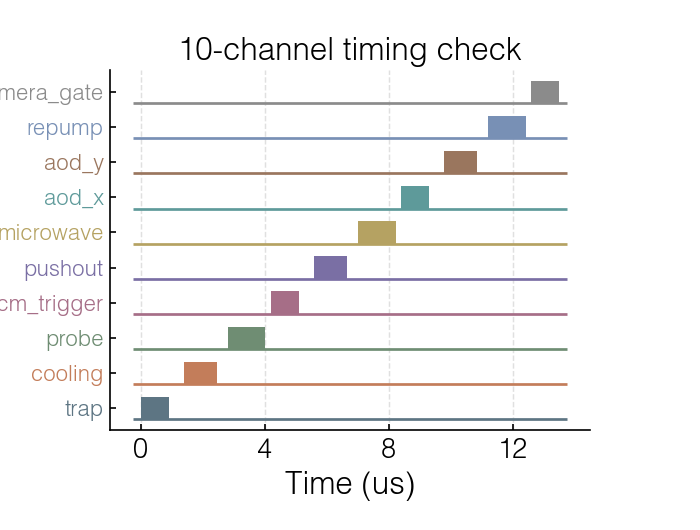

In [5]:
channels = ["trap", "cooling", "probe", "qcm_trigger", "pushout", "microwave", "aod_x", "aod_y", "repump", "camera_gate"]
pulses = [
    {"channel": channel, "start": i * 1.4e-6, "duration": 0.9e-6 + (i % 3) * 0.16e-6, "value": 1, "name": channel}
    for i, channel in enumerate(channels)
]

pulse_plot = zf.plot(
    pulses,
    kind="pulse",
    channels=channels,
    labels=("Time (s)", "Pulse", "State"),
    title="10-channel timing check",
)

## Live 2D scan

`zf.run` 接收采集函数 handle。worker 负责采集，frontend timer 负责刷新图；调用者不需要自己建线程或手动维护 controller。

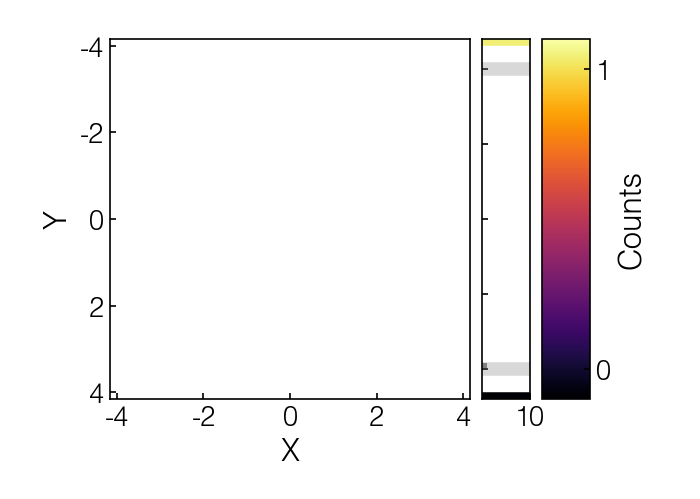

Live measurement started. Call the returned object's .stop() to stop measurement and plot.


475

In [6]:
scan_x_axis = np.linspace(-4, 4, 25)
scan_y_axis = np.linspace(-3, 3, 19)
SX, SY = np.meshgrid(scan_x_axis, scan_y_axis)
live_scan_x = np.column_stack([SX.ravel(), SY.ravel()])

def measure_scan(point):
    px, py = point
    time.sleep(0.002)
    return 400 * np.exp(-((px - 0.8) ** 2 + (py + 0.3) ** 2) / 5) + 30

live_scan = zf.run(
    live_scan_x,
    measure_scan,
    labels=("X", "Y", "Counts"),
    update_time=0.05,
)
time.sleep(1.2)
live_scan.stop()
live_scan.points_done

## Histogram with draggable threshold

右上角显示当前 threshold、双峰 Gaussian fidelity、左右比例和 `fit cut`。`fit cut` 是模型建议的交点，不会覆盖你拖动的实际 threshold。

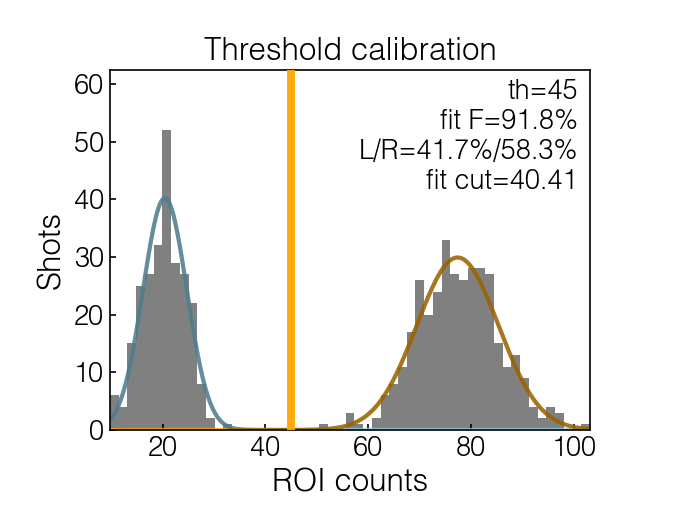

({0: 0.4166666666666667, 1: 0.5833333333333334},
 'th=45\nfit F=91.8%\nL/R=41.7%/58.3%\nfit cut=40.41')

In [7]:
rng = np.random.default_rng(6)
shots = np.r_[rng.normal(20, 4, 250), rng.normal(78, 8, 350)]

hist = zf.plot(
    shots,
    kind="hist",
    bins=55,
    thresholds=[45],
    labels=("ROI counts", "Shots", "Population"),
    title="Threshold calibration",
)
hist.fractions(), hist.stats_text.get_text()

## Continuous monitor without auto stop

`stop_when_full=False` 用于长期 monitor。实验中不需要 `.wait()`；这里为了 notebook 自动执行，最后会显式 stop。

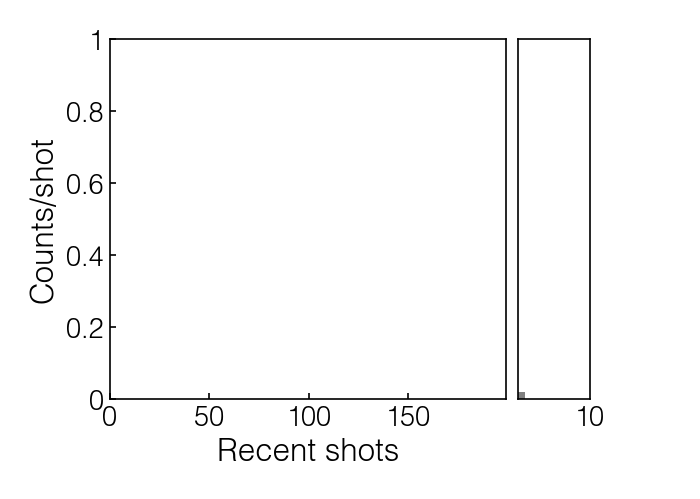

Live measurement started. Call the returned object's .stop() to stop measurement and plot.


80

In [8]:
continuous_x = np.arange(200).reshape(-1, 1)
continuous_rng = np.random.default_rng(8)

def read_continuous_count():
    time.sleep(0.002)
    return continuous_rng.poisson(50)

continuous_monitor = zf.run(
    continuous_x,
    read_continuous_count,
    kind="monitor",
    mode="roll",
    stop_when_full=False,
    labels=("Recent shots", "Counts/shot", "Counts"),
    update_time=0.05,
    max_points=80,
)
time.sleep(0.35)
continuous_monitor.stop()
continuous_monitor.points_done

In [9]:
for name in ["live_scan", "continuous_monitor"]:
    obj = globals().get(name)
    if obj is not None and hasattr(obj, "stop"):
        obj.stop()